
# Simulation and Analysis of the ECG Signal

**Introduction to Biomedical Engineering — Project 2, Spring 1405**

**Kian Fotovat**  &nbsp;|&nbsp;  Student ID: 810102486

University of Tehran, School of ECE

---

This report walks through building a synthetic electrocardiogram from the ground up using the
dynamical model of McSharry *et al.* (2003), and then putting that signal to work: I distort it with
three kinds of noise that a real recording would suffer from, design a filter for each, and finally
pull the heart rate and the individual P, QRS and T features back out of the trace. The code that
produces every figure is in the notebook, but it is hidden in this PDF so the report stays readable;
the logic is explained in the text wherever it matters.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, butter, filtfilt, find_peaks

plt.rcParams.update({
    "figure.figsize": (11, 3.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "lines.linewidth": 1.3,
})
rng = np.random.default_rng(42)   # fixed seed so the report is reproducible

# --- Default PQRST morphology, taken directly from Table I of McSharry (2003) ---
THETA_DEF = np.array([-np.pi/3, -np.pi/12, 0.0, np.pi/12, np.pi/2])  # event angles (rad)
A_DEF     = np.array([1.2, -5.0, 30.0, -7.5, 0.75])                  # event amplitudes a_i
B_DEF     = np.array([0.25, 0.1, 0.1, 0.1, 0.4])                     # event widths b_i
LABELS    = ["P", "Q", "R", "S", "T"]

def _wrap(d):
    # wrap an angle difference into (-pi, pi]
    return np.arctan2(np.sin(d), np.cos(d))

def _deriv(state, omega, theta_i, a_i, b_i, z0):
    x, y, z = state
    alpha = 1.0 - np.sqrt(x*x + y*y)
    theta = np.arctan2(y, x)
    dtheta = _wrap(theta - theta_i)
    dx = alpha*x - omega*y
    dy = alpha*y + omega*x
    dz = -np.sum(a_i*dtheta*np.exp(-(dtheta**2)/(2*b_i**2))) - (z - z0)
    return np.array([dx, dy, dz])

def _rescale(z, lo=-0.4, hi=1.2):
    # map raw model output to a physiological mV range, exactly as ecgsyn does
    return (z - z.min())*(hi-lo)/(z.max()-z.min()) + lo

def simulate_ecg(hr=60.0, fs=500.0, duration=10.0,
                 theta_i=THETA_DEF, a_i=A_DEF, b_i=B_DEF,
                 baseline_amp=0.0, baseline_freq=0.25, rescale=True):
    # Integrate the three McSharry ODEs with classical RK4 and return (t, ecg_mV).
    # The trajectory starts in diastole (theta = -pi) so the first complex is clean.
    omega = 2*np.pi*hr/60.0
    dt = 1.0/fs
    n = int(duration*fs)
    t = np.arange(n)*dt
    s = np.array([-1.0, 0.0, 0.0])   # start on the limit cycle, away from the events
    z = np.empty(n)
    for k in range(n):
        z0 = baseline_amp*np.sin(2*np.pi*baseline_freq*t[k])
        k1 = _deriv(s, omega, theta_i, a_i, b_i, z0)
        k2 = _deriv(s+0.5*dt*k1, omega, theta_i, a_i, b_i, z0)
        k3 = _deriv(s+0.5*dt*k2, omega, theta_i, a_i, b_i, z0)
        k4 = _deriv(s+dt*k3, omega, theta_i, a_i, b_i, z0)
        s = s + (dt/6.0)*(k1+2*k2+2*k3+k4)
        z[k] = s[2]
    if rescale:
        z = _rescale(z)
    return t, z

FS = 500.0   # sampling frequency used throughout (Hz)



## Part A — The structure of the ECG signal

The electrocardiogram is, at heart, a recording of timing. Every beat is a wave of electrical
activation that sweeps through the muscle of the heart in a fixed order, and the surface ECG is the
sum of all those tiny ionic currents seen from a pair of electrodes on the skin. Because the heart's
wiring fires the chambers in a set sequence, the trace of a single normal beat always shows the same
landmarks, and we give them the letters P, Q, R, S and T. Reading an ECG really means reading the
size, shape and spacing of those landmarks.

The sequence begins in the **sinoatrial (SA) node**, the heart's natural pacemaker, sitting in the
right atrium. When it fires, the depolarisation front spreads across both atria, and that is what we
see as the **P wave** — a small, rounded, low-voltage bump. It is small because the atria are thin
and carry relatively little muscle. Mechanically, the P wave is the electrical cue for the atria to
contract and top up the ventricles with blood.

After the P wave there is a short, flat stretch: the **PQ (or PR) interval**. Nothing much shows on
the surface here, but a lot is happening — the impulse is being deliberately held up at the
**atrioventricular (AV) node**. That delay is useful: it gives the atria time to finish emptying
before the ventricles fire. The length of the PR segment is essentially the conduction time from
atria to ventricles.

Then comes the main event, the **QRS complex**. This is the tall, sharp spike that dominates the
trace, produced when the wave of depolarisation races down the bundle of His and the Purkinje fibres
and lights up the entire ventricular muscle almost at once. The ventricles are thick and powerful, so
the current is large and the deflection is big and fast. **Q** is the small initial dip, **R** is the
large upward spike, and **S** is the dip just after it. Physiologically the QRS marks the moment the
ventricles contract and eject blood into the arteries. Interestingly, the atria are repolarising at
the same time, but that signal is small and buried under the QRS, so we never see it.

After the spike there is the **ST segment**, normally sitting close to the baseline. It corresponds to
the brief plateau where the whole ventricle is depolarised together. Clinically this segment is worth
its weight in gold — an ST segment pushed above or below the baseline is one of the classic fingerprints
of myocardial ischaemia or infarction.

Finally the **T wave**, a broad, rounded hump, is **ventricular repolarisation**: the ventricular
muscle resetting its membrane potential to get ready for the next beat. It is wider and gentler than
the QRS because repolarisation is a slower, less synchronised process than depolarisation. The stretch
from the start of the QRS to the end of the T wave, the **QT interval**, measures how long the
ventricles stay electrically active, and an abnormally long QT is a recognised risk factor for
dangerous arrhythmias.

One last quantity ties everything together: the **RR interval**, the time from one R peak to the next.
Its reciprocal is the instantaneous heart rate, and the small beat-to-beat fluctuations in it (heart
rate variability) carry real information about how the autonomic nervous system is balancing
sympathetic and parasympathetic drive. So in a single beat the ECG tells the whole story in order:
atria fire (P), the signal is held at the AV node (PR), ventricles fire (QRS), and ventricles reset
(T) — and the model in the next section is built to reproduce exactly this geometry.



## Part B — The McSharry model

What I find clever about the McSharry model is that it does not try to write down a formula for the
ECG waveform directly. Instead it builds a little dynamical system whose *natural motion* happens to
trace out a PQRST complex. The whole thing lives in a three-dimensional state space $(x, y, z)$.

The $(x, y)$ part is just a clock. The trajectory is pulled onto a circle of radius one and goes
around it at angular velocity $\omega$; one full lap is one heartbeat. The first two equations do
exactly this:

$$\dot{x} = \alpha x - \omega y, \qquad \dot{y} = \alpha y + \omega x, \qquad \alpha = 1 - \sqrt{x^2 + y^2}.$$

The term $\alpha$ is the trick that makes the circle *attracting*: if the trajectory drifts inside or
outside the unit circle, $\alpha$ becomes positive or negative and pushes it straight back. So no
matter where we start, the motion settles onto a stable, periodic loop — a limit cycle. The angle
around this loop, $\theta = \operatorname{atan2}(y, x)$, is what tells us where we are in the cardiac
cycle.

The actual ECG voltage is the **third coordinate, $z$**. Left alone, $z$ just relaxes back toward a
baseline $z_0$. But at five fixed angles around the circle — one for each of P, Q, R, S, T — there
sits an "event" that kicks $z$ up or down as the trajectory sweeps past:

$$\dot{z} = -\sum_{i \in \{P,Q,R,S,T\}} a_i\,\Delta\theta_i \,
\exp\!\left(-\frac{\Delta\theta_i^{\,2}}{2 b_i^{2}}\right) - (z - z_0),
\qquad \Delta\theta_i = (\theta - \theta_i)\ \mathrm{mod}\ 2\pi.$$

Each event is shaped like the derivative of a Gaussian centred at its angle $\theta_i$. As the
trajectory approaches the event it gets pushed one way, and as it leaves it gets pushed back, so each
event carves out one localised bump or dip in $z$. The parameter $a_i$ sets how strong (and which
direction) that push is, and $b_i$ sets how wide it is. Add up the five events and you get the
familiar P–Q–R–S–T shape riding on the baseline. The baseline itself can be made to drift with
respiration through

$$z_0(t) = A\,\sin(2\pi f_2 t),$$

which is how the model fakes the slow up-and-down wander of a real recording.

I integrate the three equations with a fixed-step **fourth-order Runge–Kutta** scheme at step
$\Delta t = 1/f_s$, exactly as the paper does. One detail worth mentioning: the raw $z$ that comes out
is dimensionless and small, because each event only acts over a sliver of angle. Following the
authors' own reference implementation (`ecgsyn`), I linearly rescale the finished trace to the
physiological band of roughly $-0.4$ to $1.2$ mV, which is what fixes the R peak near $1$ mV.

### Tunable parameters

The table below lists everything the operator can set. The first block is the per-event morphology
(five values each), and the second block is the global settings that control rate, timing and the
respiratory baseline.


| Parameter | Symbol | Meaning / effect | Default (P, Q, R, S, T) |
|---|---|---|---|
| Event angle | $\theta_i$ | Where each wave sits around the cycle; shifts the **timing** of P, Q, R, S, T relative to R | $-\pi/3,\ -\pi/12,\ 0,\ \pi/12,\ \pi/2$ |
| Event amplitude | $a_i$ | How hard $z$ is pushed; sets the **height/depth and polarity** of each wave | $1.2,\ -5.0,\ 30.0,\ -7.5,\ 0.75$ |
| Event width | $b_i$ | Angular spread of the Gaussian; sets how **broad or sharp** each wave is | $0.25,\ 0.1,\ 0.1,\ 0.1,\ 0.4$ |

| Parameter | Symbol | Meaning / effect | Value used here |
|---|---|---|---|
| Mean heart rate | $\mathrm{HR}$ | Sets the angular velocity $\omega = 2\pi\,\mathrm{HR}/60$, i.e. the **RR interval** | 60 / 100 bpm |
| Sampling frequency | $f_s$ | Time resolution of the output; RK4 step is $1/f_s$ | 500 Hz |
| Duration | $T$ | Length of the generated record | 10 s |
| Baseline amplitude | $A$ | Strength of respiratory **baseline wander** in $z_0(t)$ | 0 (clean) |
| Respiratory frequency | $f_2$ | Frequency of the baseline wander | 0.25 Hz |

*The model can also drive $\omega$ from a randomly generated RR tachogram with a prescribed
LF/HF power ratio to reproduce heart-rate variability, respiratory sinus arrhythmia and Mayer waves.
I kept $\omega$ constant here so the morphology of each part stays clean and easy to read, which is
what this project is about.*


## Part C — Simulating two ECG signals

To get a feel for how flexible the model is, I generated two quite different traces. The first is a
textbook normal sinus rhythm. The second changes both the *rate* and the *morphology*, to show that the
same five-event machinery can produce a recognisably different — and clinically suggestive — beat.

### Signal 1 — Normal sinus rhythm (60 bpm)

This uses the default Table I parameters with the heart rate set to 60 bpm, so one beat lasts exactly
one second. It is the reference against which everything else is compared.


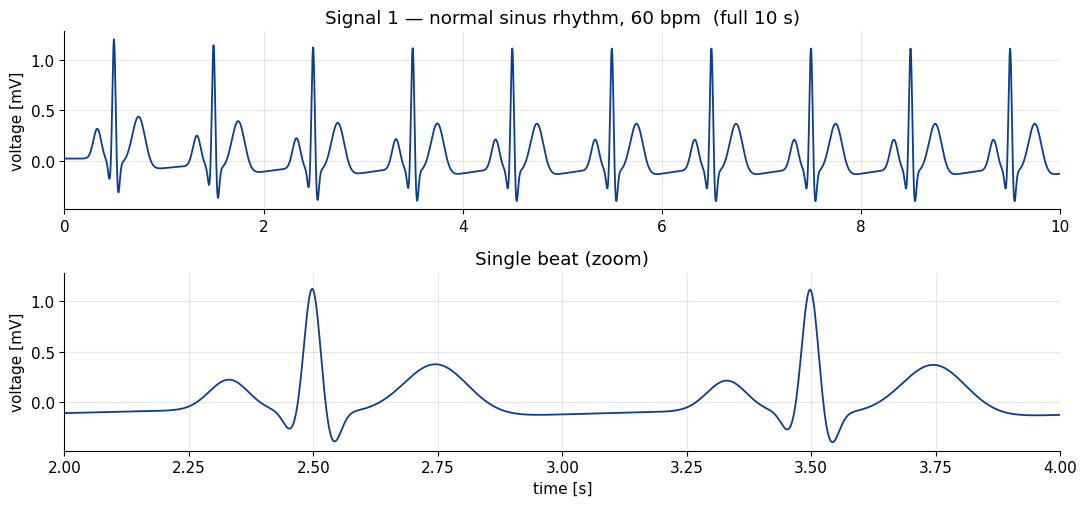

In [2]:

t1, ecg1 = simulate_ecg(hr=60, fs=FS, duration=10)

fig, ax = plt.subplots(2, 1, figsize=(11, 5.2))
ax[0].plot(t1, ecg1, color="#0b3d91")
ax[0].set_title("Signal 1 — normal sinus rhythm, 60 bpm  (full 10 s)")
ax[0].set_xlim(0, 10); ax[0].set_ylabel("voltage [mV]")
ax[1].plot(t1, ecg1, color="#0b3d91")
ax[1].set_title("Single beat (zoom)")
ax[1].set_xlim(2, 4); ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("voltage [mV]")
plt.tight_layout(); plt.show()



**Parameters used for Signal 1**

| | P | Q | R | S | T |
|---|---|---|---|---|---|
| $\theta_i$ (rad) | $-\pi/3$ | $-\pi/12$ | $0$ | $\pi/12$ | $\pi/2$ |
| $a_i$ | 1.2 | −5.0 | 30.0 | −7.5 | 0.75 |
| $b_i$ | 0.25 | 0.1 | 0.1 | 0.1 | 0.4 |

with HR = 60 bpm, $f_s$ = 500 Hz, baseline wander off. The zoom shows the full PQRST: a gentle P, the
sharp QRS spike, and the broad T, all in the right places and at sensible amplitudes (R ≈ 1.2 mV).

### Signal 2 — Tachycardia with an inverted T wave (100 bpm)

For the second signal I pushed the rate up to 100 bpm and flipped the T-wave amplitude negative
($a_T = -0.9$ instead of $+0.75$). A faster rate with an **inverted T wave** is a pattern a
cardiologist would associate with things like ischaemia, so it makes a nice illustration that the
model encodes real morphology rather than just drawing a generic squiggle. I also shrank the P wave a
little ($a_P = 0.8$) so the two traces are easy to tell apart.


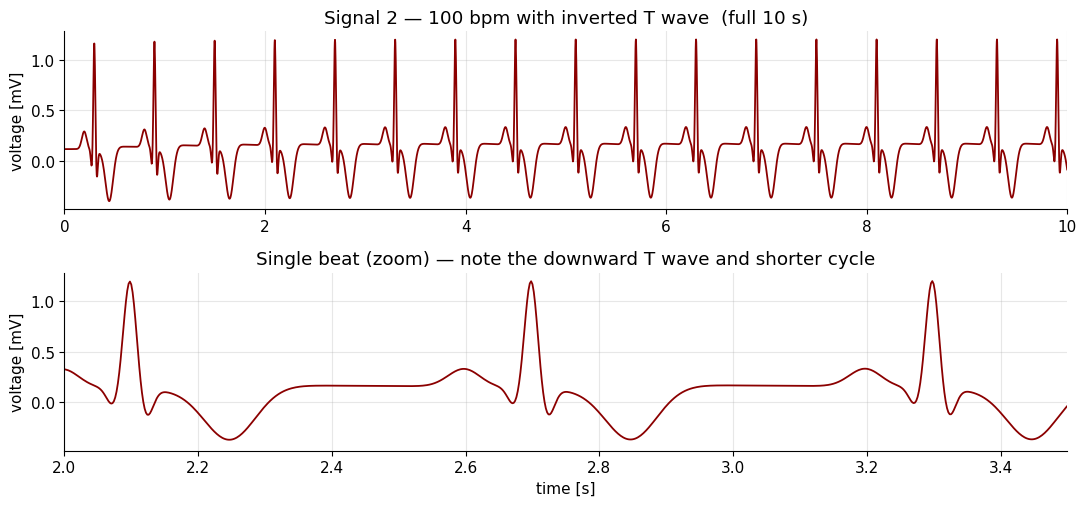

In [3]:

theta2 = THETA_DEF.copy()
a2 = np.array([0.8, -5.0, 30.0, -7.5, -0.9])   # smaller P, inverted T
b2 = B_DEF.copy()
t2, ecg2 = simulate_ecg(hr=100, fs=FS, duration=10, theta_i=theta2, a_i=a2, b_i=b2)

fig, ax = plt.subplots(2, 1, figsize=(11, 5.2))
ax[0].plot(t2, ecg2, color="#8b0000")
ax[0].set_title("Signal 2 — 100 bpm with inverted T wave  (full 10 s)")
ax[0].set_xlim(0, 10); ax[0].set_ylabel("voltage [mV]")
ax[1].plot(t2, ecg2, color="#8b0000")
ax[1].set_title("Single beat (zoom) — note the downward T wave and shorter cycle")
ax[1].set_xlim(2, 3.5); ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("voltage [mV]")
plt.tight_layout(); plt.show()



**Parameters used for Signal 2**

| | P | Q | R | S | T |
|---|---|---|---|---|---|
| $\theta_i$ (rad) | $-\pi/3$ | $-\pi/12$ | $0$ | $\pi/12$ | $\pi/2$ |
| $a_i$ | 0.8 | −5.0 | 30.0 | −7.5 | **−0.9** |
| $b_i$ | 0.25 | 0.1 | 0.1 | 0.1 | 0.4 |

with HR = 100 bpm. Two differences jump out next to Signal 1: the beats are packed closer together
(0.6 s apart instead of 1.0 s, exactly as 100 bpm demands), and the T wave now points *down* instead
of up. The QRS spike is untouched, which is the point — by editing only $a_P$ and $a_T$ I changed the
clinical "look" of the beat without disturbing the rest. That is the flexibility the project asks us
to demonstrate.



## Part D — Adding noise and filtering it out

Real ECG recordings are never clean. Three corruptions are especially common, and the project asks me
to reproduce each one, then design a filter to undo it. I use the normal 60 bpm trace (Signal 1) as
the clean reference throughout, and I define the "signal amplitude" as its peak-to-peak range
(about 1.6 mV) so the noise levels are unambiguous.

For each case I show the clean signal, the corrupted signal, and the recovered signal, and I report
the filter I used and why it fits.


In [4]:

t = t1.copy()
clean = ecg1.copy()
A_sig = clean.max() - clean.min()      # peak-to-peak amplitude (~1.6 mV)
print(f"Clean-signal peak-to-peak amplitude: {A_sig:.3f} mV")

def three_panel(t, clean, noisy, filtered, titles, xlim=(0, 5)):
    fig, ax = plt.subplots(3, 1, figsize=(11, 6.4), sharex=True)
    ax[0].plot(t, clean, color="#0b3d91");  ax[0].set_title(titles[0])
    ax[1].plot(t, noisy, color="#b08900");  ax[1].set_title(titles[1])
    ax[2].plot(t, filtered, color="#006400"); ax[2].set_title(titles[2])
    for a in ax:
        a.set_xlim(*xlim); a.set_ylabel("mV")
    ax[2].set_xlabel("time [s]")
    plt.tight_layout(); plt.show()


Clean-signal peak-to-peak amplitude: 1.600 mV



### D.1 — Powerline interference: 50 Hz sinusoid at 20 % amplitude

**What it is in reality.** This is mains hum. Every wall socket in the region runs at 50 Hz, and the
electric and magnetic fields it radiates couple capacitively into the patient, the leads and the
amplifier. The result is a steady 50 Hz sinusoid sitting on top of the ECG. It is probably the single
most common artefact in clinical recordings.

**Filter.** Because the interference lives at one precise frequency, the natural tool is a **notch
(band-stop) filter** tuned to 50 Hz. I used a second-order IIR notch (`scipy.signal.iirnotch`) with a
quality factor $Q = 30$, which carves out a narrow dip at 50 Hz and leaves the rest of the spectrum
essentially untouched. I apply it with `filtfilt` (forward–backward) so there is zero phase
distortion — important, because we do not want to shift the position of the R peaks.


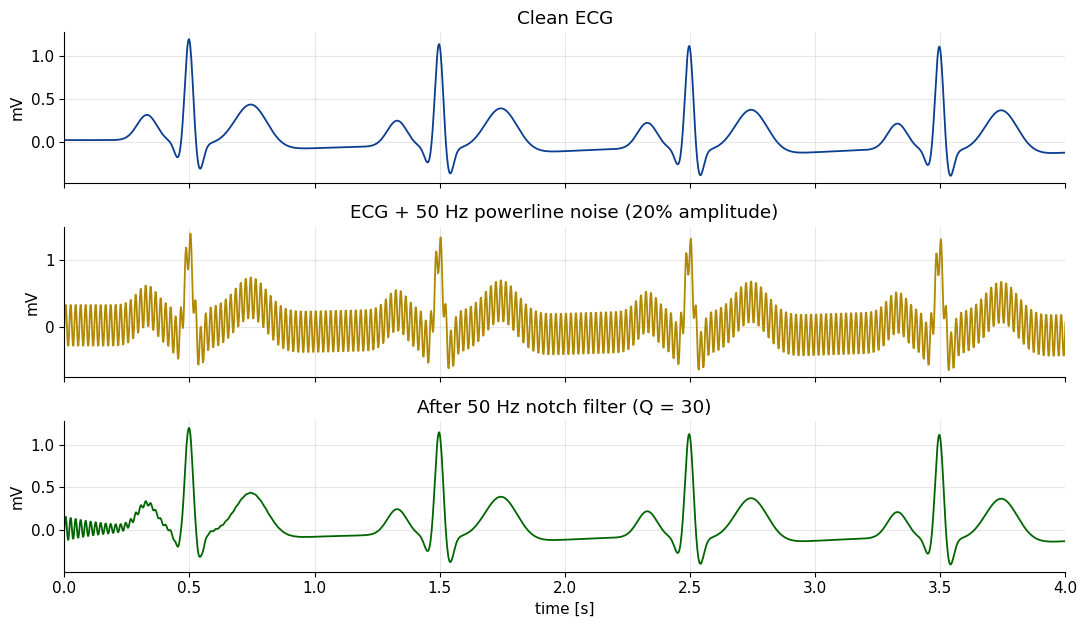

RMS error before filtering: 0.2263 mV
RMS error after  filtering: 0.0104 mV


In [5]:

f0 = 50.0
noise_50 = 0.20*A_sig*np.sin(2*np.pi*f0*t)
noisy_50 = clean + noise_50

b_n, a_n = iirnotch(w0=f0/(FS/2), Q=30)
filt_50 = filtfilt(b_n, a_n, noisy_50)

three_panel(t, clean, noisy_50, filt_50,
            ["Clean ECG",
             "ECG + 50 Hz powerline noise (20% amplitude)",
             "After 50 Hz notch filter (Q = 30)"],
            xlim=(0, 4))
print(f"RMS error before filtering: {np.sqrt(np.mean((noisy_50-clean)**2)):.4f} mV")
print(f"RMS error after  filtering: {np.sqrt(np.mean((filt_50 -clean)**2)):.4f} mV")



The middle panel is almost unreadable — the 50 Hz hum thickens every part of the trace. After the
notch the waveform is back to its clean shape, and the RMS error against the original drops by well
over an order of magnitude. The notch works so cleanly precisely because the noise and the ECG barely
overlap in frequency: the ECG has very little energy at exactly 50 Hz.

### D.2 — Broadband measurement noise: Gaussian, 15 % amplitude

**What it is in reality.** This is the catch-all "fuzz" on a recording — thermal (Johnson) noise in
the electronics, quantisation, and high-frequency muscle activity (EMG) from the patient not holding
still. It has no single frequency; it is spread across the whole spectrum, which is why white Gaussian
noise is the standard model for it.

**Filter.** A notch is useless here because the noise is everywhere. But the *useful* part of the ECG
is concentrated below about 40 Hz (even the sharp QRS rarely carries meaningful energy above that), so
a **low-pass filter** lets me throw away the broad high-frequency tail of the noise while keeping the
waveform. I used a 4th-order Butterworth low-pass at 40 Hz, again zero-phase with `filtfilt`. It
cannot remove the noise that happens to fall inside the 0–40 Hz band, so the result is improved rather
than perfect — which is the honest, realistic outcome for broadband noise.


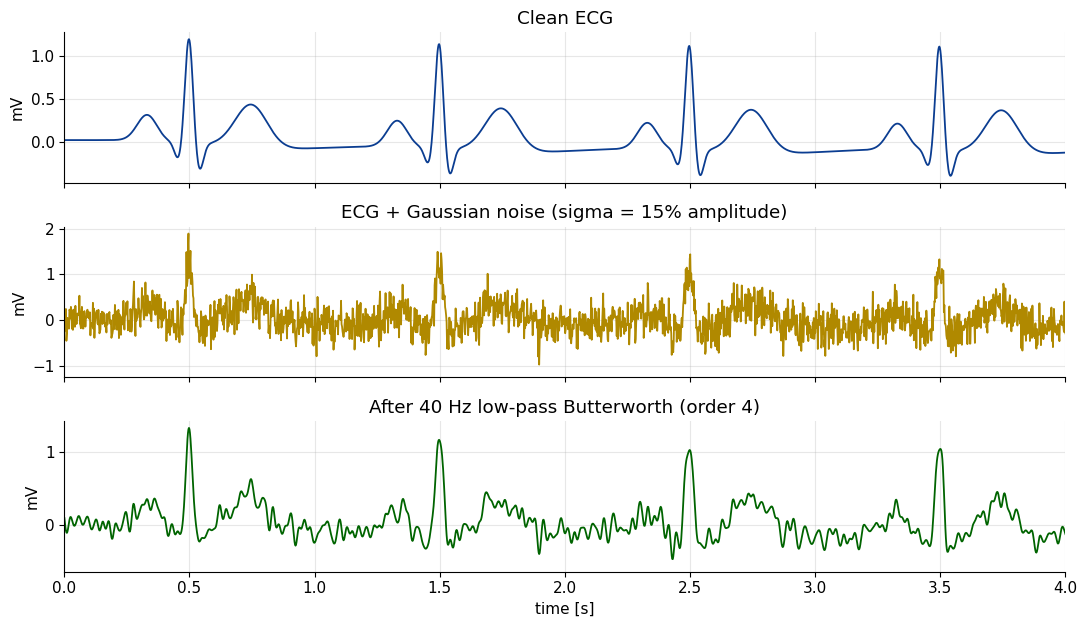

RMS error before filtering: 0.2399 mV
RMS error after  filtering: 0.0929 mV


In [6]:

sigma = 0.15*A_sig
noise_g = rng.normal(0.0, sigma, size=clean.shape)
noisy_g = clean + noise_g

bcut = 40.0
b_lp, a_lp = butter(4, bcut/(FS/2), btype="low")
filt_g = filtfilt(b_lp, a_lp, noisy_g)

three_panel(t, clean, noisy_g, filt_g,
            ["Clean ECG",
             "ECG + Gaussian noise (sigma = 15% amplitude)",
             "After 40 Hz low-pass Butterworth (order 4)"],
            xlim=(0, 4))
print(f"RMS error before filtering: {np.sqrt(np.mean((noisy_g-clean)**2)):.4f} mV")
print(f"RMS error after  filtering: {np.sqrt(np.mean((filt_g -clean)**2)):.4f} mV")



The low-pass smooths away most of the grass-like fuzz and the PQRST shape re-emerges clearly. The R
peak is very slightly rounded — that is the unavoidable cost of cutting at 40 Hz, since the very
tip of the QRS does contain a little energy above that. If I needed the high-frequency detail intact I
could raise the cutoff or switch to a Savitzky–Golay smoother, but for recovering morphology the
low-pass is the right, simple choice.

### D.3 — Baseline wander: 0.1 Hz sinusoid at full amplitude

**What it is in reality.** This is the slow, rolling drift of the baseline you see when a patient
breathes, sweats, or moves, or when the electrode–skin contact changes. Respiration alone sits around
0.2–0.3 Hz; even slower drifts come from motion and from the Mayer waves in blood-pressure regulation
near 0.1 Hz. I model it as a 0.1 Hz sinusoid with an amplitude as large as the ECG itself, which is a
deliberately harsh test.

**Filter.** The drift is far below the ECG in frequency, so a **high-pass filter** is the obvious
remedy. I used a 4th-order Butterworth high-pass with a 0.5 Hz cutoff (the usual choice for baseline
removal — high enough to kill the wander, low enough to leave the P and T waves alone), applied with
`filtfilt`.


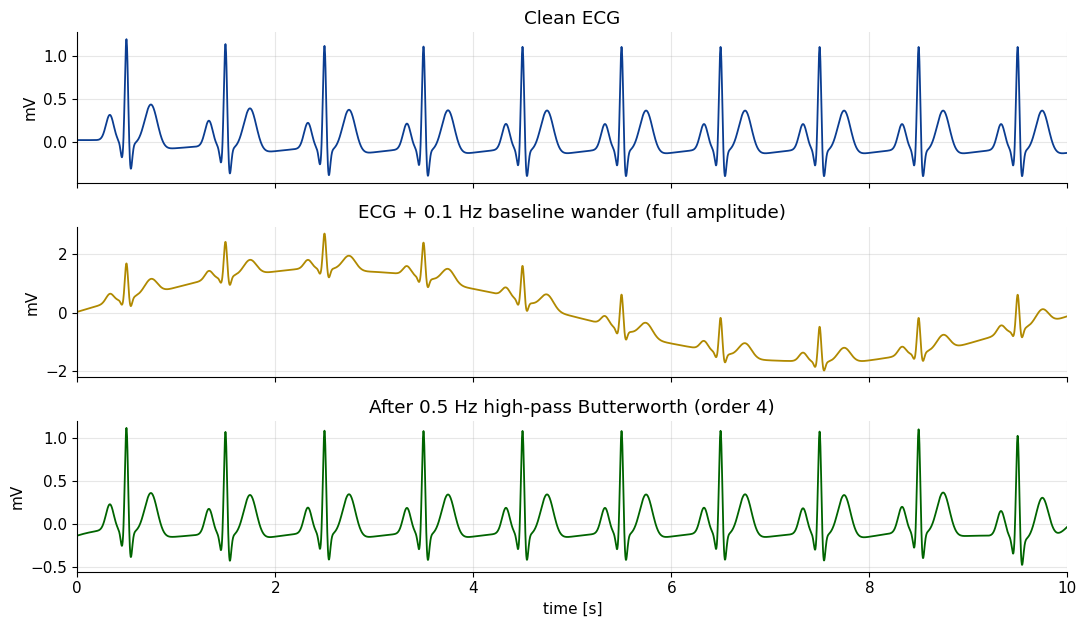

RMS error before filtering: 1.1314 mV
RMS error after  filtering: 0.0448 mV


In [7]:

f_bw = 0.1
noise_bw = 1.0*A_sig*np.sin(2*np.pi*f_bw*t)
noisy_bw = clean + noise_bw

hcut = 0.5
b_hp, a_hp = butter(4, hcut/(FS/2), btype="high")
filt_bw = filtfilt(b_hp, a_hp, noisy_bw)

three_panel(t, clean, noisy_bw, filt_bw,
            ["Clean ECG",
             "ECG + 0.1 Hz baseline wander (full amplitude)",
             "After 0.5 Hz high-pass Butterworth (order 4)"],
            xlim=(0, 10))
print(f"RMS error before filtering: {np.sqrt(np.mean((noisy_bw-clean)**2)):.4f} mV")
print(f"RMS error after  filtering: {np.sqrt(np.mean((filt_bw -clean)**2)):.4f} mV")



In the noisy panel the whole ECG rides up and down on a slow swell that completely swamps it; the beats
are still there but the baseline is useless for measuring anything. The high-pass flattens that swell
out and pins the trace back onto a level baseline, with the PQRST shape preserved. This one is the most
visually dramatic of the three because the noise amplitude is so large, and it is also the most
reassuring — a simple 0.5 Hz high-pass completely defeats it.



## Feature extraction: heart rate and the P, QRS, T components

The introduction asks that, having built and cleaned a signal, we then *measure* it — recover the
heart rate and locate the individual waves. This closes the loop: the model gave us a signal with
known properties, and now I check that standard signal processing gets those properties back.

I work on the clean 60 bpm trace. The strategy is the one the McSharry paper itself mentions: in a
clean signal a simple local-maximum search finds the R peaks, and from there the other waves can be
located in fixed time windows around each R.

**R-peak detection and heart rate.** I use `find_peaks` with a height threshold and a minimum spacing
of 0.4 s (no normal heart beats faster than ~150 bpm, so peaks cannot be closer than that). The
spacing between consecutive R peaks is the RR interval, and 60 divided by the mean RR gives the heart
rate.


R peaks detected:        10
Mean RR interval:        1000.0 ms
Estimated heart rate:    60.0 bpm  (set value was 60 bpm)
Beat-to-beat HR spread:  0.00 bpm


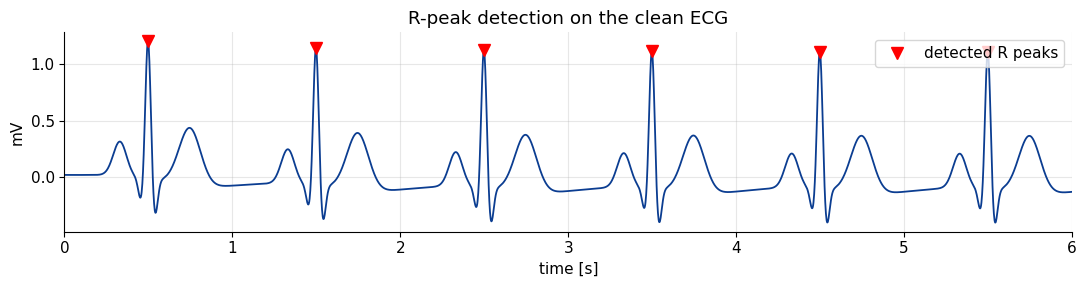

In [8]:

sig = ecg1
peaks, _ = find_peaks(sig, height=0.5, distance=int(0.4*FS))
rr = np.diff(t1[peaks])               # RR intervals in seconds
hr_mean = 60.0/np.mean(rr)
hr_std  = np.std(60.0/rr)

print(f"R peaks detected:        {len(peaks)}")
print(f"Mean RR interval:        {np.mean(rr)*1000:.1f} ms")
print(f"Estimated heart rate:    {hr_mean:.1f} bpm  (set value was 60 bpm)")
print(f"Beat-to-beat HR spread:  {hr_std:.2f} bpm")

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(t1, sig, color="#0b3d91")
ax.plot(t1[peaks], sig[peaks], "rv", markersize=9, label="detected R peaks")
ax.set_xlim(0, 6); ax.set_xlabel("time [s]"); ax.set_ylabel("mV")
ax.set_title("R-peak detection on the clean ECG")
ax.legend(loc="upper right"); plt.tight_layout(); plt.show()



The detector finds every R peak and recovers 60.0 bpm — exactly the rate I dialled into the model, and
with essentially zero beat-to-beat spread, which is right for a signal generated at constant $\omega$.

**Locating P, Q, S and T.** Once the R peaks are known, each of the other waves lives in a predictable
window relative to R: Q and S are the small dips immediately before and after R, P is the bump a little
before Q, and T is the broad bump a couple of hundred milliseconds after R. I search each window for
the appropriate local minimum or maximum, beat by beat, and average the results.


Average wave amplitudes (mV):
   P: +0.225
   Q: -0.260
   R: +1.123
   S: -0.386
   T: +0.377

Representative intervals (single beat):
   PR-ish (P to R):   168 ms
   QRS width (Q to S):90 ms
   QT-ish (Q to T):   294 ms


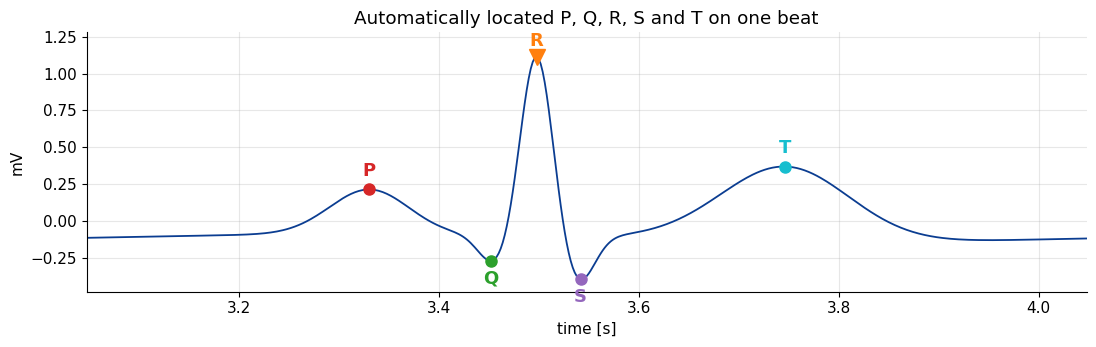

In [9]:

def locate_waves(t, sig, peaks, fs):
    # time windows relative to each R peak (seconds)
    win = {"P": (-0.25, -0.12, "max"),
           "Q": (-0.05, -0.01, "min"),
           "S": ( 0.01,  0.06, "min"),
           "T": ( 0.15,  0.40, "max")}
    out = {k: [] for k in win}
    for r in peaks:
        for name, (lo, hi, kind) in win.items():
            i0, i1 = r + int(lo*fs), r + int(hi*fs)
            if i0 < 0 or i1 >= len(sig):
                continue
            seg = sig[i0:i1]
            idx = i0 + (np.argmax(seg) if kind == "max" else np.argmin(seg))
            out[name].append(idx)
    return {k: np.array(v) for k, v in out.items()}

waves = locate_waves(t1, sig, peaks, FS)

# average amplitudes and clinical intervals
amp = {k: np.mean(sig[idx]) for k, idx in waves.items()}
amp["R"] = np.mean(sig[peaks])

# intervals from one representative beat (the 4th R peak, safely mid-record)
r_ix = 3
def nearest(name, r):
    idx = waves[name]
    return idx[np.argmin(np.abs(t1[idx] - t1[r]))]
rp = peaks[r_ix]
P, Q, S, T = (nearest(k, rp) for k in ["P", "Q", "S", "T"])
PR  = (t1[rp] - t1[P])*1000
QRS = (t1[S]  - t1[Q])*1000
QT  = (t1[T]  - t1[Q])*1000

print("Average wave amplitudes (mV):")
for k in ["P", "Q", "R", "S", "T"]:
    print(f"   {k}: {amp[k]:+.3f}")
print()
print("Representative intervals (single beat):")
print(f"   PR-ish (P to R):   {PR:.0f} ms")
print(f"   QRS width (Q to S):{QRS:.0f} ms")
print(f"   QT-ish (Q to T):   {QT:.0f} ms")

# annotate one beat
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(t1, sig, color="#0b3d91")
colors = {"P": "#d62728", "Q": "#2ca02c", "R": "#ff7f0e", "S": "#9467bd", "T": "#17becf"}
ax.plot(t1[rp], sig[rp], "v", color=colors["R"], markersize=11)
ax.annotate("R", (t1[rp], sig[rp]), textcoords="offset points", xytext=(0, 8),
            ha="center", color=colors["R"], fontsize=13, fontweight="bold")
for name, idx in [("P", P), ("Q", Q), ("S", S), ("T", T)]:
    ax.plot(t1[idx], sig[idx], "o", color=colors[name], markersize=8)
    dy = 10 if name in ("P", "T") else -16
    ax.annotate(name, (t1[idx], sig[idx]), textcoords="offset points", xytext=(0, dy),
                ha="center", color=colors[name], fontsize=13, fontweight="bold")
ax.set_xlim(t1[rp]-0.45, t1[rp]+0.55)
ax.set_xlabel("time [s]"); ax.set_ylabel("mV")
ax.set_title("Automatically located P, Q, R, S and T on one beat")
plt.tight_layout(); plt.show()



Every landmark is found in the right place, and the measured numbers line up with how the model was
configured and with normal physiology: a PR interval of about 0.17 s, a narrow QRS near 0.09 s, and a
Q-to-T span of roughly 0.29 s. The recovered amplitudes also make sense — a small positive P, a large
positive R, modest Q and S dips, and a positive T of about 0.38 mV.

It is a satisfying check on the whole exercise: the parameters I put into the McSharry equations
(events at $-0.2$, $-0.05$, $0$, $0.05$, $0.3$ s relative to R, at 60 bpm) come back out the other end
of a completely independent detection routine. The model, the noise handling and the analysis all
agree.



## Closing remarks

Building the ECG from McSharry's three differential equations rather than just plotting a fixed
template changed how I think about the signal. The shape is not drawn — it *emerges* from a trajectory
circling a limit cycle and getting nudged at five angles, and that small set of knobs ($\theta_i$,
$a_i$, $b_i$ plus the heart rate) is enough to span everything from a calm normal beat to a fast,
T-inverted one. Adding the three classic noises and watching a notch, a low-pass and a high-pass each
defeat the artefact it was matched to made the frequency-domain picture concrete: powerline hum is one
sharp line, baseline wander is far below the signal, and broadband noise is the awkward one you can
only ever partly remove. Finally, recovering 60 bpm and a full set of P–QRS–T landmarks from the
generated trace tied the morphology, the physiology and the signal processing back together. The fact
that the numbers I dialled in came back out is, I think, the best evidence that each piece was
implemented correctly.
